# Flux Calibrations Sept 19a (Oct 18 twilights)

In [1]:
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy import units as u
from scipy.interpolate import interp1d

from magE.functions import air
from magE.spec.natural_spline import *
from magE.spec.spec_classes import *

In [2]:
# Reduced by BN
# _multispec -> with the -2D flag
# _multi -> without the -2D flag

dataPath = '/home/benjamin/Documents/analogs/calib/mage19a/mage19atf/'

# In this script you must calib

J1226 = MageMultispec.from_fname(dataPath + 'j1226+0415_multi.fits')
J2119 = MageMultispec.from_fname(dataPath + 'j2119+0052_multi.fits')

# Read GD108 and LTT7379 1D spectral data
# GD108 and LTT7379 multispec from CarPy

gd108 = MageMultispec.from_fname(dataPath + 'gd108_multi.fits')
ltt7379 = MageMultispec.from_fname(dataPath + 'ltt7379_multi.fits')
hr4963 = MageMultispec.from_fname(dataPath + 'hr4963_multi.fits')

In [3]:
refPath = '/home/benjamin/Documents/analogs/calib/mage19a/'

# gd108 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16), 2 -> flux (mJy)

gd108_ref = pd.read_csv(refPath + 'fgd108.dat', header=None, 
                           sep='\s+', engine='python')
simple_gd108 = SimpleSpectrum(lda=gd108_ref[0], 
                                 flux=gd108_ref[1]*1e-16)

# ltt7379 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16)

ltt7379_ref = pd.read_csv(refPath +'fltt7379.dat', header=None, sep='\s+', 
                          engine='python')
simple_ltt7379 = SimpleSpectrum(lda=ltt7379_ref[0], flux=ltt7379_ref[1]*1e-16)

# hr4963 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16)

hr4963_ref = pd.read_csv(refPath +'fhr4963.dat', header=None, sep='\s+', 
                          engine='python')
simple_hr4963 = SimpleSpectrum(lda=hr4963_ref[0], flux=hr4963_ref[1]*1e-16)

# Reference Star Spline: HR4963

In [4]:
x_hr = air(simple_hr4963.lda)
y_hr = simple_hr4963.flux

mask_hr = (x_hr < 3867) + (x_hr > 3903) * (x_hr < 3947) \
         + (x_hr > 3997) * (x_hr < 4056) \
         + (x_hr > 4165) * (x_hr < 4265) \
         + (x_hr > 4425) * (x_hr < 4765) \
         + (x_hr > 4980) * (x_hr < 6440) \
         + (x_hr > 6650) * (x_hr < 6808) \
         + (x_hr > 6970) * (x_hr < 7130) \
         + (x_hr > 7802) * (x_hr < 8075) \
         + (x_hr > 8266) * (x_hr < 8426) \
         + (x_hr > 8777) * (x_hr < 8830) \
         + (x_hr > 9099) * (x_hr < 9196) \
         + (x_hr > 9702) * (x_hr < 9960) \
         + (x_hr > 10120)

knots_hr = np.array([3342, 3400, 3450, 3500, 3550, 3600, 3630,
                     3741, 3781, 3859, 4025, 4215, 4500, 4600,
                     5000, 6000, 6700, 6750, 7000, 7100, 7900,
                     8300, 8800, 9100, 9800, 102000])

In [5]:
# building spline based model
model_hr = get_natural_cubic_spline_model(x=simple_hr4963.lda[mask_hr],
                                          y=simple_hr4963.flux[mask_hr],
                                          minval=np.min(simple_hr4963.lda[mask_hr]),
                                          maxval=np.max(simple_hr4963.lda[mask_hr]),
                                          knots=knots_hr)

# getting flux
y_est_custom_model_hr = model_hr.predict(simple_hr4963.lda)

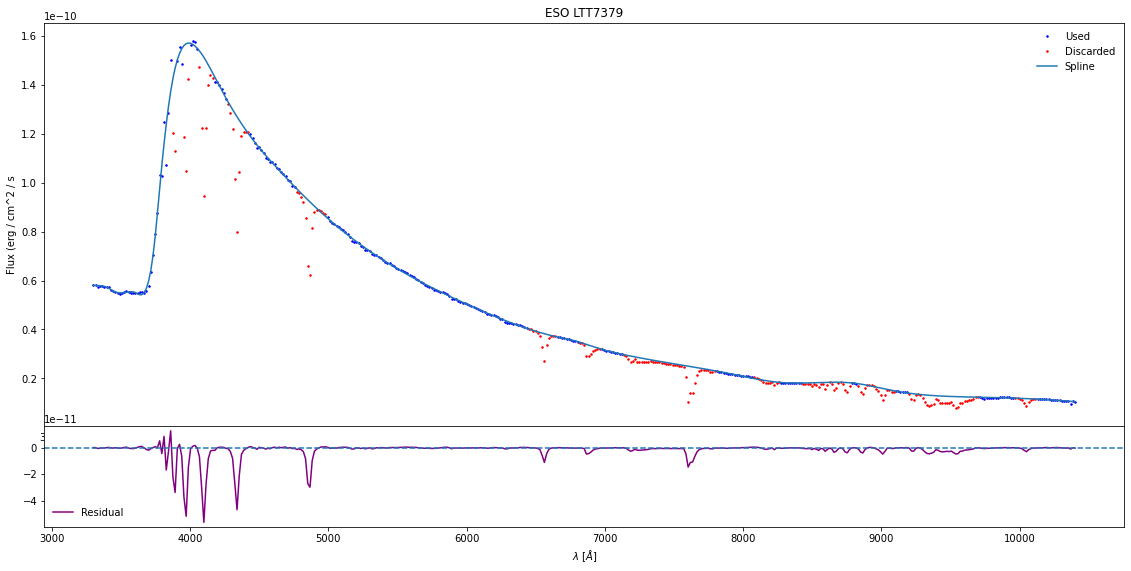

In [6]:
%matplotlib inline

fig = plt.figure(1)
fig.set_size_inches(15, 7)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(simple_hr4963.lda[mask_hr], simple_hr4963.flux[mask_hr], 
        ls='', marker='.', markersize=3, label='Used', color='blue')
ax.plot(simple_hr4963.lda[np.logical_not(mask_hr)], 
        simple_hr4963.flux[np.logical_not(mask_hr)], 
        ls='', marker='.', markersize=3, label='Discarded', color='red')
ax.plot(simple_hr4963.lda, y_est_custom_model_hr, label='Spline')
ax.legend(frameon=False)
ax.set_ylabel('Flux (erg / cm^2 / s')
ax.set_title('ESO LTT7379')

ax1.plot(x_hr, y_hr - y_est_custom_model_hr, label='Residual', 
         color='purple')
ax1.legend(frameon=False)
ax1.axhline(0, ls='--')
ax1.set_xlabel(r'$\lambda$ [$\AA$]');

In [7]:
reference_hrflux = interp1d(simple_hr4963.lda,
                              model_hr.predict(simple_hr4963.lda),
                              kind='linear', bounds_error=False,
                              fill_value='extrapolate', assume_sorted=True)

## Order 6

In [8]:
xhr6 = hr4963.wavelength(6)
yhr6 = hr4963.flux(6)

mask6_hr = (xhr6 > 9504.07) * (xhr6 < 9512) \
          + (xhr6 > 9572) * (xhr6 < 9576) \
          + (xhr6 > 9683) * (xhr6 < 9687) \
          + (xhr6 > 9844) * (xhr6 < 9849) \
          + (xhr6 > 10070) * (xhr6 < 10100) \
          + (xhr6 > 10200) * (xhr6 < 10210) \
          + (xhr6 > 10146) * (xhr6 < 10153) \
          + (xhr6 > 10301) * (xhr6 < 10304) \
          + (xhr6 > 10370)

knots6_hr = np.array([9510, 9574, 9685, 9847, 10090, 10150,
                      10205, 10302.5, 10400, 11000])

In [9]:
model_custom6_hr = get_natural_cubic_spline_model(x=xhr6[mask6_hr],
                                                  y=yhr6[mask6_hr],
                                                  minval=np.min(xhr6),
                                                  maxval=np.max(xhr6),
                                                  knots=knots6_hr)

y_est_custom6_hr = model_custom6_hr.predict(hr4963.wavelength(6))

In [10]:
obs_flux6_hr = spectres(simple_hr4963.lda, hr4963.wavelength(6), 
                     y_est_custom6_hr, verbose=False)

factor6_hr = reference_hrflux(simple_hr4963.lda)/obs_flux6_hr

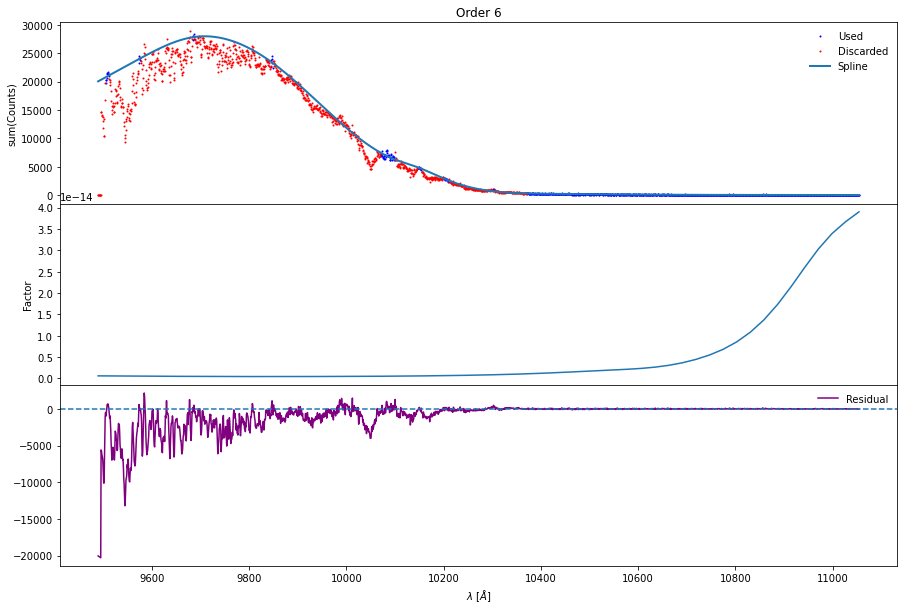

In [11]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr6[mask6_hr], yhr6[mask6_hr], ls='', marker='.', markersize=2,
            label='Used', color='blue')
axs[0].plot(xhr6[np.logical_not(mask6_hr)], yhr6[np.logical_not(mask6_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(6), y_est_custom6_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 6')

axs[1].plot(simple_hr4963.lda, factor6_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(6), hr4963.flux(6) - y_est_custom6_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 7

In [12]:
xhr7 = hr4963.wavelength(7)
yhr7 = hr4963.flux(7)

mask7_hr = (xhr7 > 8170) * (xhr7 < 8174) \
        + (xhr7 > 8236) * (xhr7 < 8240) \
        + (xhr7 > 8340) * (xhr7 < 8355) \
        + (xhr7 > 8418) * (xhr7 < 8421) \
        + (xhr7 > 8478) * (xhr7 < 8485) \
        + (xhr7 > 8573) * (xhr7 < 8577) \
        + (xhr7 > 8622) * (xhr7 < 8627) \
        + (xhr7 > 8700) * (xhr7 < 8712) \
        + (xhr7 > 8919) * (xhr7 < 8926) \
        + (xhr7 > 9049) * (xhr7 < 9057) \
        + (xhr7 > 9193) * (xhr7 < 9208) \
        + (xhr7 > 9447) * (xhr7 < 9452)

knots7_hr = np.array([8172, 8238, 8350, 8419, 8480, 8575, 8625, 8625, 8706,
                      8923, 9053, 9200, 9450])

In [13]:
model_custom7_hr = get_natural_cubic_spline_model(x=xhr7[mask7_hr], y=yhr7[mask7_hr], 
                                               minval=np.min(xhr7), maxval=np.max(xhr7), 
                                               knots=knots7_hr)

y_est_custom7_hr = model_custom7_hr.predict(hr4963.wavelength(7))

In [14]:
obs_flux7_hr = spectres(simple_hr4963.lda, hr4963.wavelength(7), 
                     y_est_custom7_hr, verbose=False)

factor7_hr = reference_hrflux(simple_hr4963.lda)/obs_flux7_hr

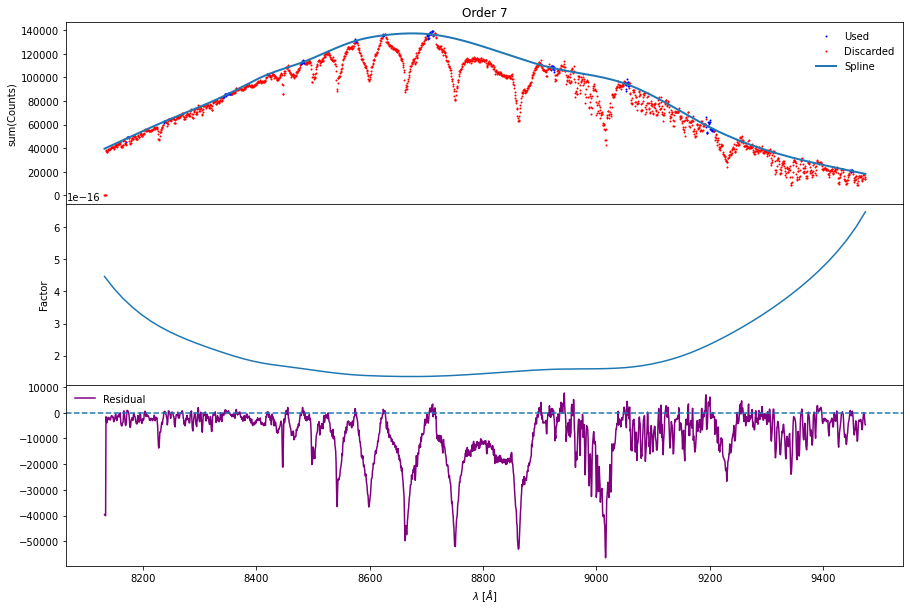

In [15]:
%matplotlib inline

fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr7[mask7_hr], yhr7[mask7_hr], ls='', marker='.', markersize=2,
            label='Used', color='blue')
axs[0].plot(xhr7[np.logical_not(mask7_hr)], yhr7[np.logical_not(mask7_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(7), y_est_custom7_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 7')

axs[1].plot(simple_hr4963.lda, factor7_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(7), hr4963.flux(7) - y_est_custom7_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 8

In [16]:
yhr8_1 = hr4963.flux(8)[5:833]
xhr8_1 = hr4963.wavelength(8)[5:833]

yhr8_int = hr4963.flux(8)[833:1032]
xhr8_int = hr4963.wavelength(8)[833:1032]

yhr8_2 = hr4963.flux(8)[1032:]
xhr8_2 = hr4963.wavelength(8)[1032:]

mask8_1_hr = (xhr8_1 > 7123) * (xhr8_1 < 7144) \
           + (xhr8_1 > 7219) * (xhr8_1 < 7221) \
           + (xhr8_1 > 7378) * (xhr8_1 < 7380) \
           + (xhr8_1 > 7443) * (xhr8_1 < 7446) \
           + (xhr8_1 > 7499) * (xhr8_1 < 7501) \
           + (xhr8_1 > 7573) * (xhr8_1 < 7576)

mask8_2_hr = (xhr8_2 > 7734) * (xhr8_2 < 7738) \
           + (xhr8_2 > 7788) * (xhr8_2 < 7793) \
           + (xhr8_2 > 7912) * (xhr8_2 < 7914) \
           + (xhr8_2 > 7994) * (xhr8_2 < 7997) \
           + (xhr8_2 > 8079) * (xhr8_2 < 8080) \
           + (xhr8_2 > 8245)

knots8_1_hr = np.array([7130, 7220, 7379, 7445, 7500, 7575])
knots8_2_hr = np.array([7736, 7790, 7913, 7996, 8079.5, 8260, 8284])

In [17]:
model_custom8_1_hr = get_natural_cubic_spline_model(x=xhr8_1[mask8_1_hr],
                                                 y=yhr8_1[mask8_1_hr],
                                                 minval=np.min(xhr8_1),
                                                 maxval=np.max(xhr8_1),
                                                 knots=knots8_1_hr)
y_est_custom8_1_hr = model_custom8_1_hr.predict(hr4963.wavelength(8)[:833])

interp_y8_hr = interp1d(xhr8_int, yhr8_int, kind='linear', bounds_error=False, 
                     fill_value=np.nan, assume_sorted=True)
y_est_custom8_int_hr = interp_y8_hr(xhr8_int)

model_custom8_2_hr = get_natural_cubic_spline_model(x=xhr8_2[mask8_2_hr],
                                                 y=yhr8_2[mask8_2_hr],
                                                 minval=np.min(xhr8_2),
                                                 maxval=np.max(xhr8_2),
                                                 knots=knots8_2_hr)
y_est_custom8_2_hr = model_custom8_2_hr.predict(xhr8_2)

y_est_custom8_hr = np.concatenate((y_est_custom8_1_hr, y_est_custom8_int_hr, 
                                y_est_custom8_2_hr))

In [18]:
obs_flux8_hr = spectres(simple_hr4963.lda, hr4963.wavelength(8), 
                     y_est_custom8_hr, verbose=False)
factor8_hr = reference_hrflux(simple_hr4963.lda)/obs_flux8_hr

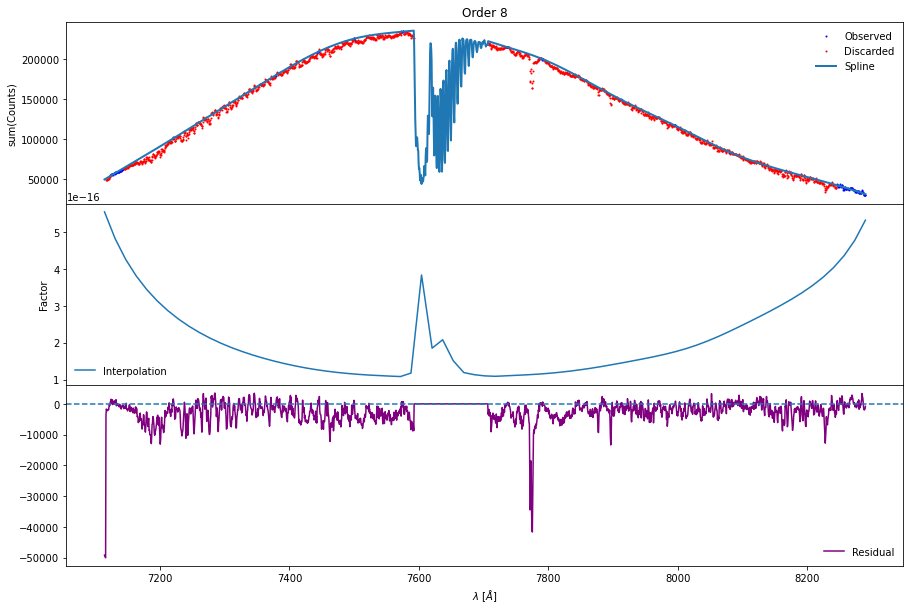

In [19]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr8_1[mask8_1_hr], yhr8_1[mask8_1_hr],
            ls='', marker='.', markersize=2, label='Observed', color='blue')
axs[0].plot(xhr8_2[mask8_2_hr], yhr8_2[mask8_2_hr],
            ls='', marker='.', markersize=2, color='blue')
axs[0].plot(xhr8_1[np.logical_not(mask8_1_hr)], yhr8_1[np.logical_not(mask8_1_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(xhr8_2[np.logical_not(mask8_2_hr)], yhr8_2[np.logical_not(mask8_2_hr)],
            ls='', marker='.', markersize=2, color='red')
axs[0].plot(hr4963.wavelength(8), y_est_custom8_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 8')

axs[1].plot(simple_hr4963.lda, factor8_hr, label='Interpolation')
axs[1].set_ylabel('Factor')
axs[1].legend(frameon=False)

axs[2].plot(hr4963.wavelength(8), hr4963.flux(8) - y_est_custom8_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 9

In [20]:
yhr9_1 = hr4963.flux(9)[:1056]
xhr9_1 = hr4963.wavelength(9)[:1056]

yhr9_int = hr4963.flux(9)[1056:1218]
xhr9_int = hr4963.wavelength(9)[1056:1218]

yhr9_2 = hr4963.flux(9)[1218:]
xhr9_2 = hr4963.wavelength(9)[1218:]

mask9_1_hr = (xhr9_1 > 6329) * (xhr9_1 < 6342) \
           + (xhr9_1 > 6380) * (xhr9_1 < 6447) \
           + (xhr9_1 > 6602) * (xhr9_1 < 6669) \
           + (xhr9_1 > 6774) * (xhr9_1 < 6778) \
           + (xhr9_1 > 6844) * (xhr9_1 < 6860)

mask9_2_hr = (xhr9_2 > 6965) * (xhr9_2 < 6974) \
           + (xhr9_2 > 7041) * (xhr9_2 < 7049) \
           + (xhr9_2 > 7112) * (xhr9_2 < 7119) \
           + (xhr9_2 > 7321) * (xhr9_2 < 7360)

knots9_1_hr = np.array([6338, 6390, 6430, 6420, 6620, 6647, 6776, 6855])
knots9_2_hr = np.array([6970, 7045, 7116, 7350, 7359])

In [21]:
model_custom9_1_hr = get_natural_cubic_spline_model(x=xhr9_1[mask9_1_hr], 
                                                 y=yhr9_1[mask9_1_hr], 
                                                 minval=np.min(xhr9_1), 
                                                 maxval=np.max(xhr9_1), 
                                                 knots=knots9_1_hr)
y_est_custom9_1_hr = model_custom9_1_hr.predict(hr4963.wavelength(9)[:1056])

interp_y9_hr = interp1d(xhr9_int, yhr9_int, kind='linear', bounds_error=False, 
                     fill_value=np.nan, assume_sorted=True)
y_est_custom9_int_hr = interp_y9_hr(xhr9_int)

model_custom9_2_hr = get_natural_cubic_spline_model(x=xhr9_2[mask9_2_hr],
                                                 y=yhr9_2[mask9_2_hr],
                                                 minval=np.min(xhr9_2),
                                                 maxval=np.max(xhr9_2),
                                                 knots=knots9_2_hr)
y_est_custom9_2_hr = model_custom9_2_hr.predict(xhr9_2)

y_est_custom9_hr = np.concatenate((y_est_custom9_1_hr, 
                                   y_est_custom9_int_hr, 
                                   y_est_custom9_2_hr))

In [22]:
obs_flux9_hr = spectres(simple_hr4963.lda, hr4963.wavelength(9), 
                     y_est_custom9_hr, verbose=False)
factor9_hr = reference_hrflux(simple_hr4963.lda)/obs_flux9_hr

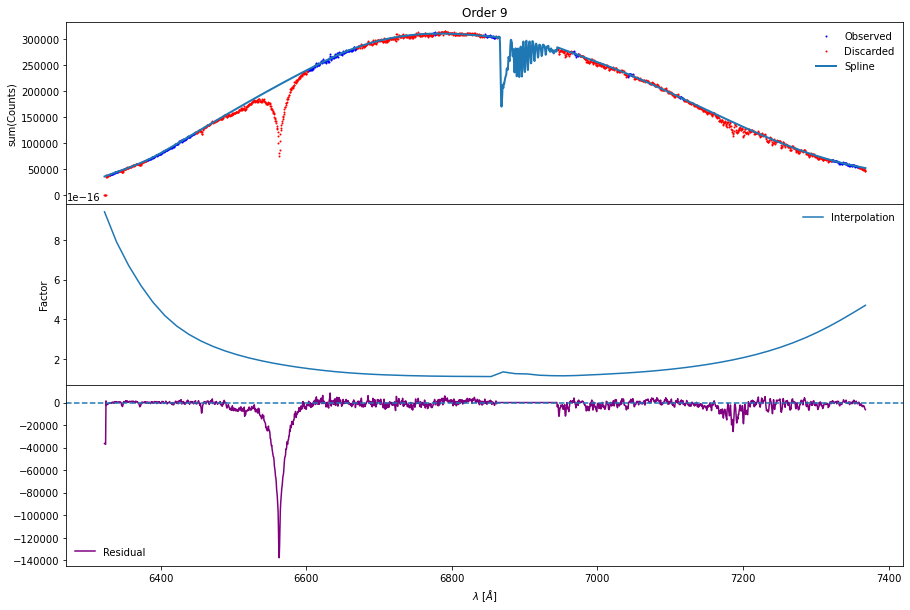

In [23]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr9_1[mask9_1_hr], yhr9_1[mask9_1_hr],
            ls='', marker='.', markersize=2, label='Observed', color='blue')
axs[0].plot(xhr9_2[mask9_2_hr], yhr9_2[mask9_2_hr],
            ls='', marker='.', markersize=2, color='blue')
axs[0].plot(xhr9_1[np.logical_not(mask9_1_hr)], yhr9_1[np.logical_not(mask9_1_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(xhr9_2[np.logical_not(mask9_2_hr)], yhr9_2[np.logical_not(mask9_2_hr)],
            ls='', marker='.', markersize=2, color='red')
axs[0].plot(hr4963.wavelength(9), y_est_custom9_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 9')

axs[1].plot(simple_hr4963.lda, factor9_hr, label='Interpolation')
axs[1].set_ylabel('Factor')
axs[1].legend(frameon=False)

axs[2].plot(hr4963.wavelength(9), hr4963.flux(9) - y_est_custom9_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 10

In [24]:
yhr10 = hr4963.flux(10)
xhr10 = hr4963.wavelength(10)

mask10_hr = (xhr10 > 5692) * (xhr10 < 5811) \
           + (xhr10 > 5933) * (xhr10 < 5935) \
           + (xhr10 > 6055) * (xhr10 < 6059) \
           + (xhr10 > 6150) * (xhr10 < 6155) \
           + (xhr10 > 6226) * (xhr10 < 6230) \
           + (xhr10 > 6268) * (xhr10 < 6272) \
           + (xhr10 > 6377) * (xhr10 < 6380) \
           + (xhr10 > 6477) * (xhr10 < 6504) \
           + (xhr10 > 6616) * (xhr10 < 6625)

knots10_hr = np.array([5698, 5710, 5758, 5800, 5934, 6057, 6153,
                       6228, 6270, 6378, 6490, 6620])

In [25]:
model_custom10_hr = get_natural_cubic_spline_model(x=xhr10[mask10_hr],
                                                y=yhr10[mask10_hr],
                                                minval=np.min(xhr10),
                                                maxval=np.max(xhr10),
                                                knots=knots10_hr)
y_est_custom10_hr = model_custom10_hr.predict(hr4963.wavelength(10))

In [26]:
obs_flux10_hr = spectres(simple_hr4963.lda, hr4963.wavelength(10), 
                      y_est_custom10_hr, verbose=False)
factor10_hr = reference_hrflux(simple_hr4963.lda)/obs_flux10_hr

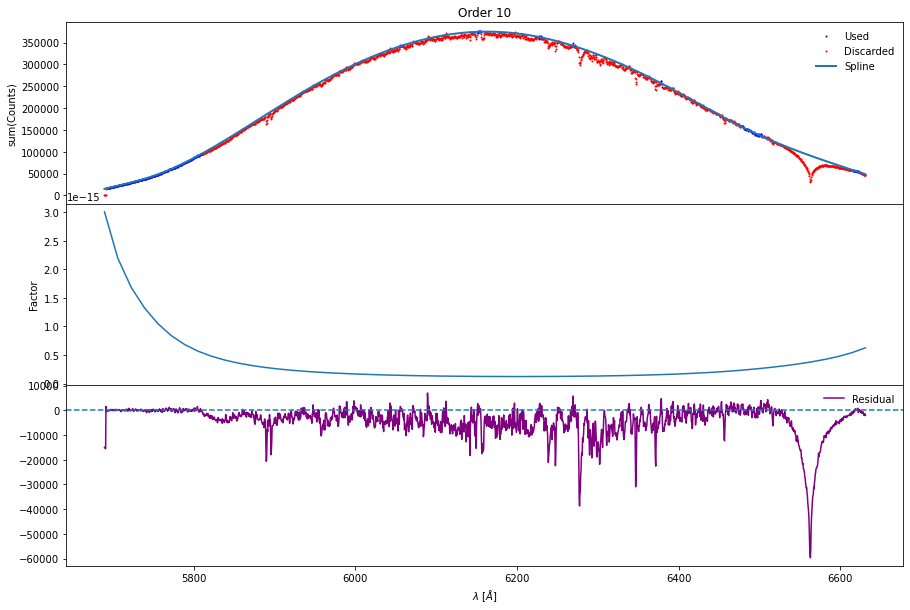

In [27]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr10[mask10_hr], yhr10[mask10_hr], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xhr10[np.logical_not(mask10_hr)], yhr10[np.logical_not(mask10_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(10), y_est_custom10_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 10')

axs[1].plot(simple_hr4963.lda, factor10_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(10), hr4963.flux(10) - y_est_custom10_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 11

In [28]:
xhr11 = hr4963.wavelength(11)
yhr11 = hr4963.flux(11)

mask11_hr = (xhr11 > 5174) * (xhr11 < 5177) \
            + (xhr11 > 5219) * (xhr11 < 5224)\
            + (xhr11 > 5286) * (xhr11 < 5289) \
            + (xhr11 > 5390) * (xhr11 < 5394) \
            + (xhr11 > 5351) * (xhr11 < 5361) \
            + (xhr11 > 5470) * (xhr11 < 5471.3) \
            + (xhr11 > 5536) * (xhr11 < 5541) \
            + (xhr11 > 5621.5) * (xhr11 < 5623) \
            + (xhr11 > 5758) * (xhr11 < 5761) \
            + (xhr11 > 5844) * (xhr11 < 5848) \
            + (xhr11 > 5904)

knots11_hr = np.array([5175, 5222, 5288, 5392, 5356, 5471, 5538,
                       5622, 5760, 5846, 5908, 5940, 5978, 6021])

In [29]:
model_custom11_hr = get_natural_cubic_spline_model(x=xhr11[mask11_hr],
                                                   y=yhr11[mask11_hr],
                                                   minval=np.min(xhr11),
                                                   maxval=np.max(xhr11),
                                                   knots=knots11_hr)
y_est_custom11_hr = model_custom11_hr.predict(hr4963.wavelength(11))

In [30]:
obs_flux11_hr = spectres(simple_hr4963.lda, hr4963.wavelength(11), 
                      y_est_custom11_hr, verbose=False)
factor11_hr = reference_hrflux(simple_hr4963.lda)/obs_flux11_hr

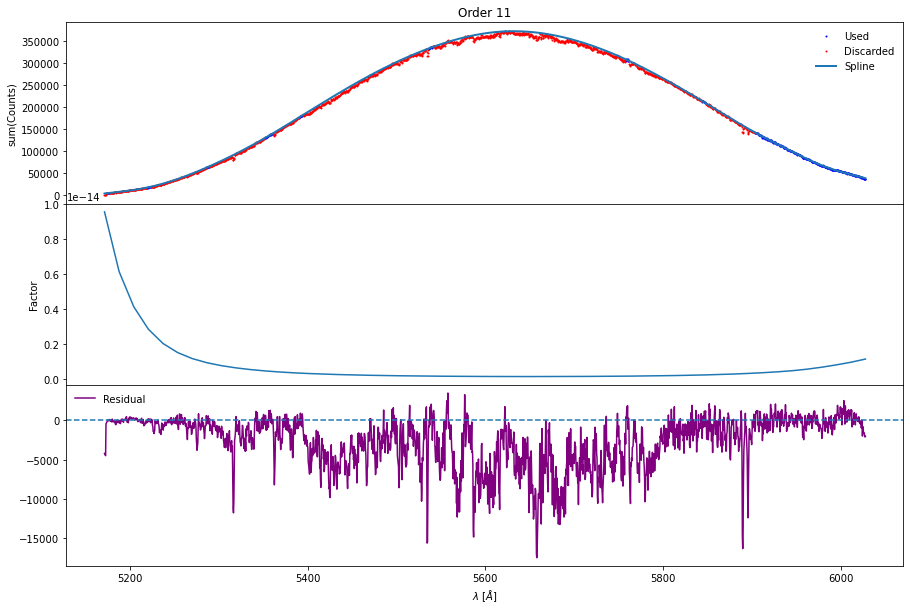

In [31]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr11[mask11_hr], yhr11[mask11_hr],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xhr11[np.logical_not(mask11_hr)], yhr11[np.logical_not(mask11_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(11), y_est_custom11_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 11')

axs[1].plot(simple_hr4963.lda, factor11_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(11), hr4963.flux(11) - y_est_custom11_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 12

In [32]:
yhr12 = hr4963.flux(12)
xhr12 = hr4963.wavelength(12)

mask12_hr = (xhr12 > 4742) * (xhr12 < 4831) \
           + (xhr12 > 4913) * (xhr12 < 4916) \
           + (xhr12 > 4960) * (xhr12 < 4961.3) \
           + (xhr12 > 5032.5) * (xhr12 < 5034.5) \
           + (xhr12 > 5076) * (xhr12 < 5078) \
           + (xhr12 > 5135) * (xhr12 < 5136.5) \
           + (xhr12 > 5175) * (xhr12 < 5176.5) \
           + (xhr12 > 5244) * (xhr12 < 5246) \
           + (xhr12 > 5318) * (xhr12 < 5320) \
           + (xhr12 > 5420)

knots12_hr = np.array([4750, 4800, 4914, 4960.5, 5033, 5077,
                       5136, 5176, 5245, 5319, 5440, 5470, 5520])

In [33]:
model_custom12_hr = get_natural_cubic_spline_model(x=xhr12[mask12_hr],
                                                y=yhr12[mask12_hr],
                                                minval=np.min(xhr12),
                                                maxval=np.max(xhr12),
                                                knots=knots12_hr)
y_est_custom12_hr = model_custom12_hr.predict(hr4963.wavelength(12))

In [34]:
obs_flux12_hr = spectres(simple_hr4963.lda, hr4963.wavelength(12), 
                      y_est_custom12_hr, verbose=False)
factor12_hr = reference_hrflux(simple_hr4963.lda)/obs_flux12_hr

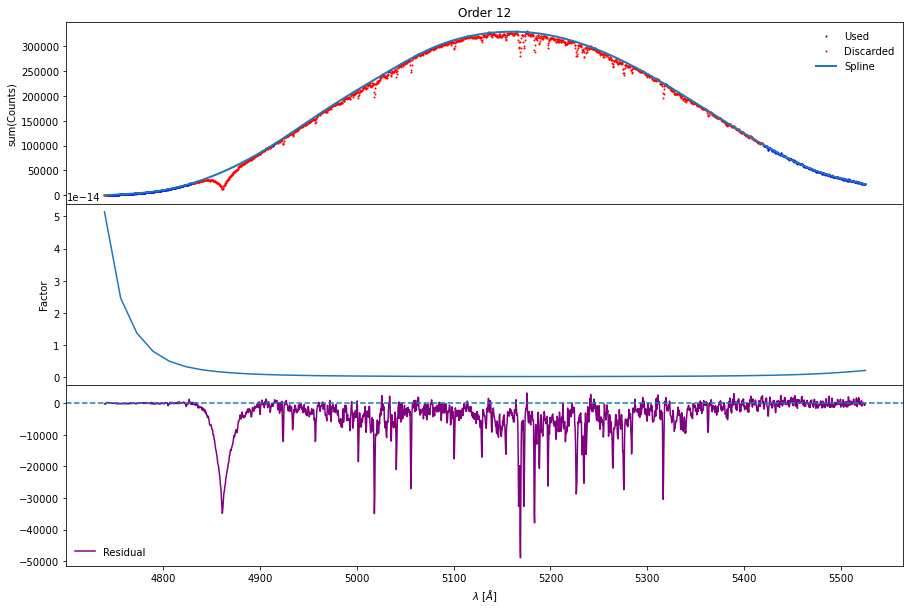

In [35]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr12[mask12_hr], yhr12[mask12_hr], ls='',
            marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xhr12[np.logical_not(mask12_hr)], yhr12[np.logical_not(mask12_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(12), y_est_custom12_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 12')

axs[1].plot(simple_hr4963.lda, factor12_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(12), hr4963.flux(12) - y_est_custom12_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 13

In [36]:
yhr13 = hr4963.flux(13)
xhr13 = hr4963.wavelength(13)

mask13_hr = (xhr13 > 4376) * (xhr13 < 4468) \
          + (xhr13 > 4475) * (xhr13 < 4524) \
          + (xhr13 > 4567) * (xhr13 < 4570) \
          + (xhr13 > 4657) * (xhr13 < 4661) \
          + (xhr13 > 4704.5) * (xhr13 < 4706) \
          + (xhr13 > 4757.5) * (xhr13 < 4760) \
          + (xhr13 > 4816) * (xhr13 < 4819) \
          + (xhr13 > 4961)

knots13_hr = np.array([4379, 4429, 4486, 4520, 4568, 4659, 4705, 4758.5,
                       4818, 4962, 5016, 5051, 5091])

In [37]:
model_custom13_hr = get_natural_cubic_spline_model(x=xhr13[mask13_hr],
                                                y=yhr13[mask13_hr],
                                                minval=np.min(xhr13),
                                                maxval=np.max(xhr13),
                                                knots=knots13_hr)
y_est_custom13_hr = model_custom13_hr.predict(hr4963.wavelength(13))

In [38]:
obs_flux13_hr = spectres(simple_hr4963.lda, hr4963.wavelength(13),
                      y_est_custom13_hr, verbose=False)
factor13_hr = reference_hrflux(simple_hr4963.lda)/obs_flux13_hr

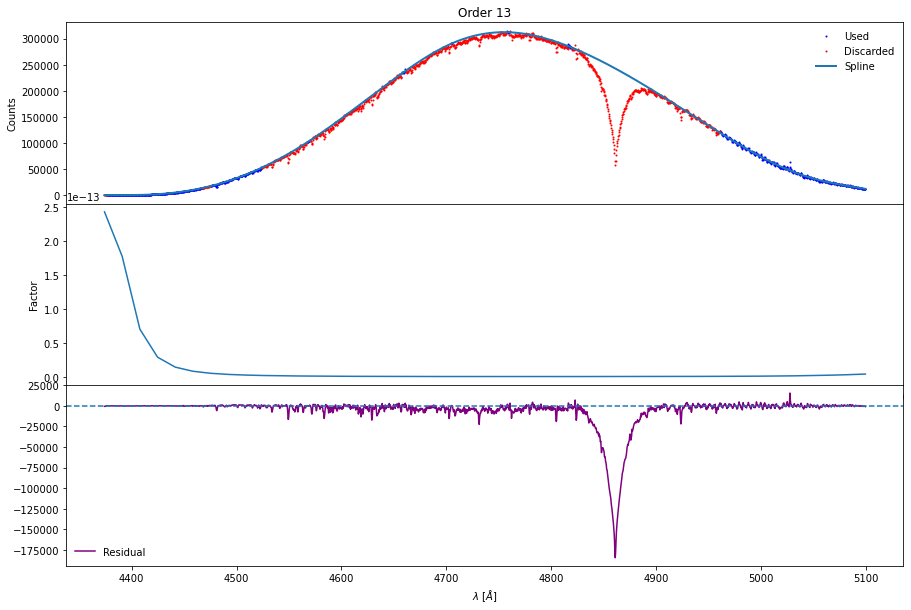

In [39]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr13[mask13_hr], yhr13[mask13_hr], ls='',
            marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xhr13[np.logical_not(mask13_hr)], yhr13[np.logical_not(mask13_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(13), y_est_custom13_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 13')

axs[1].plot(simple_hr4963.lda, factor13_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(13), hr4963.flux(13) - y_est_custom13_hr, 
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 14

In [40]:
yhr14 = hr4963.flux(14)
xhr14 = hr4963.wavelength(14)

mask14_hr = (xhr14 > 4062) * (xhr14 < 4221) \
          + (xhr14 > 4280) * (xhr14 < 4282) \
          + (xhr14 > 4371) * (xhr14 < 4373) \
          + (xhr14 > 4428) * (xhr14 < 4430) \
          + (xhr14 > 4509) * (xhr14 < 4513) \
          + (xhr14 > 4609) * (xhr14 < 4678) \
          + (xhr14 > 4692)

knots14_hr = np.array([4068, 4127, 4142, 4281, 4372, 4429,
                       4510, 4614, 4646, 4701, 4729])

In [41]:
model_custom14_hr = get_natural_cubic_spline_model(x=xhr14[mask14_hr], 
                                                y=yhr14[mask14_hr], 
                                                minval=np.min(xhr14), 
                                                maxval=np.max(xhr14), 
                                                knots=knots14_hr)
y_est_custom14_hr = model_custom14_hr.predict(hr4963.wavelength(14))

In [42]:
obs_flux14_hr = spectres(simple_hr4963.lda, hr4963.wavelength(14),
                         y_est_custom14_hr, verbose=False)
factor14_hr = reference_hrflux(simple_hr4963.lda)/obs_flux14_hr

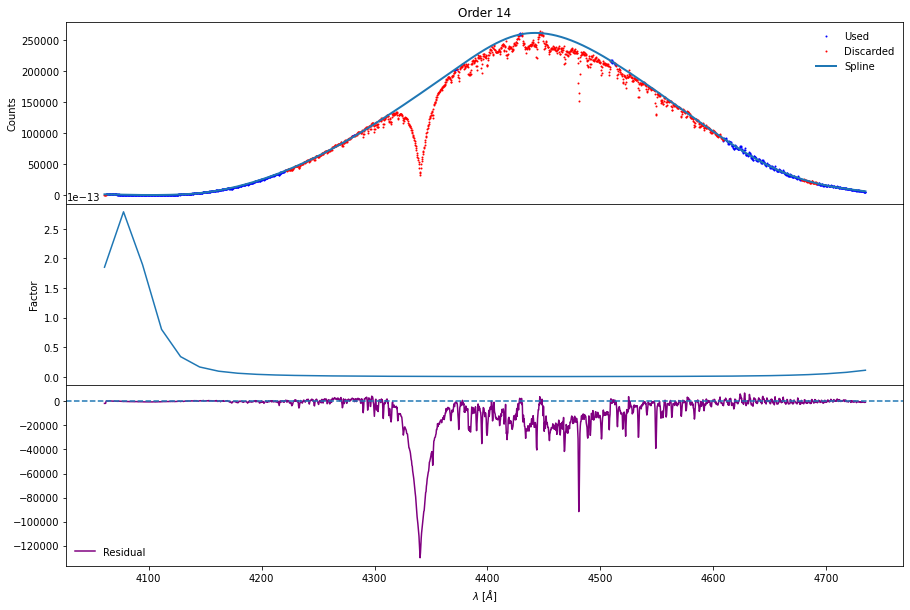

In [43]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr14[mask14_hr], yhr14[mask14_hr], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xhr14[np.logical_not(mask14_hr)], yhr14[np.logical_not(mask14_hr)], ls='',
            marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(14), y_est_custom14_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 14')

axs[1].plot(simple_hr4963.lda, factor14_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(14), hr4963.flux(14) - y_est_custom14_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 15

In [44]:
yhr15 = hr4963.flux(15)
xhr15 = hr4963.wavelength(15)

mask15_hr = (xhr15 > 3790.1) * (xhr15 < 3793) \
          + (xhr15 > 3809) * (xhr15 < 3874) \
          + (xhr15 > 3903) * (xhr15 < 3924) \
          + (xhr15 > 3945) * (xhr15 < 3950) \
          + (xhr15 > 4016) * (xhr15 < 4019) \
          + (xhr15 > 4058) * (xhr15 < 4062) \
          + (xhr15 > 4135) * (xhr15 < 4141) \
          + (xhr15 > 4164) * (xhr15 < 4166) \
          + (xhr15 > 4192) * (xhr15 < 4194) \
          + (xhr15 > 4262) * (xhr15 < 4266) \
          + (xhr15 > 4315) * (xhr15 < 4321) \
          + (xhr15 > 4357)

knots15_hr = np.array([3792, 3820, 3850, 3910, 3920, 3947, 4017, 4060,
                       4138, 4165, 4193, 4264, 4320, 4367, 4402])

In [45]:
model_custom15_hr = get_natural_cubic_spline_model(x=xhr15[mask15_hr],
                                                y=yhr15[mask15_hr],
                                                minval=np.min(xhr15),
                                                maxval=np.max(xhr15),
                                                knots=knots15_hr)
y_est_custom15_hr = model_custom15_hr.predict(hr4963.wavelength(15))

In [46]:
obs_flux15_hr = spectres(simple_hr4963.lda, hr4963.wavelength(15),
                      y_est_custom15_hr, verbose=False)
factor15_hr = reference_hrflux(simple_hr4963.lda)/obs_flux15_hr

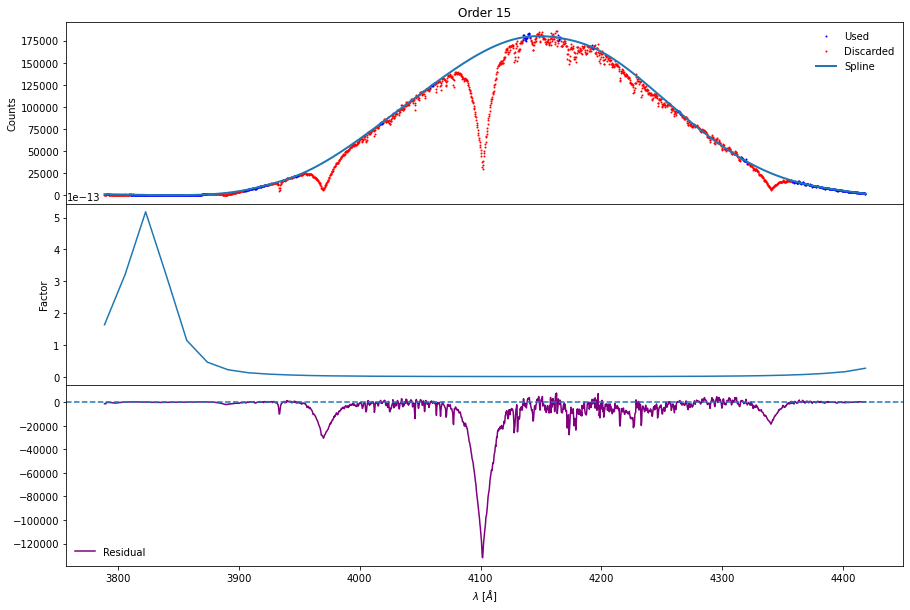

In [47]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr15[mask15_hr], yhr15[mask15_hr], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xhr15[np.logical_not(mask15_hr)], yhr15[np.logical_not(mask15_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(15), y_est_custom15_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 15')

axs[1].plot(simple_hr4963.lda, factor15_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(15), hr4963.flux(15) - y_est_custom15_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 16

In [48]:
yhr16 = hr4963.flux(16)
xhr16 = hr4963.wavelength(16)

mask16_hr = (xhr16 > 3553) * (xhr16 < 3694) \
          + (xhr16 > 3739) * (xhr16 < 3744) \
          + (xhr16 > 3783) * (xhr16 < 3785) \
          + (xhr16 > 3816) * (xhr16 < 3818) \
          + (xhr16 > 3860) * (xhr16 < 3861.9)\
          + (xhr16 > 3924) * (xhr16 < 3926) \
          + (xhr16 > 4017) * (xhr16 < 4019) \
          + (xhr16 > 4042.4) * (xhr16 < 4043.6) \
          + (xhr16 > 4110)

knots16_hr = np.array([3560, 3580, 3640, 3690, 3742, 3784, 3817,
                       3861, 3925, 4018, 4043, 4120, 4138])

In [49]:
model_custom16_hr = get_natural_cubic_spline_model(x=xhr16[mask16_hr],
                                                y=yhr16[mask16_hr],
                                                minval=np.min(xhr16),
                                                maxval=np.max(xhr16),
                                                knots=knots16_hr)
y_est_custom16_hr = model_custom16_hr.predict(hr4963.wavelength(16))

In [50]:
obs_flux16_hr = spectres(simple_hr4963.lda, hr4963.wavelength(16),
                      y_est_custom16_hr, verbose=False)
factor16_hr = reference_hrflux(simple_hr4963.lda)/obs_flux16_hr

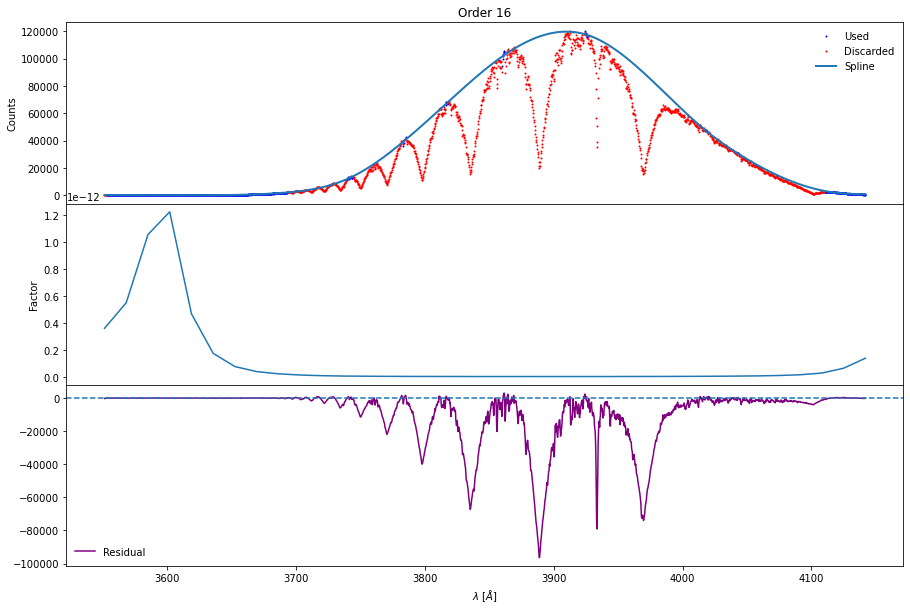

In [51]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr16[mask16_hr], yhr16[mask16_hr], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xhr16[np.logical_not(mask16_hr)], yhr16[np.logical_not(mask16_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(16), y_est_custom16_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 16')

axs[1].plot(simple_hr4963.lda, factor16_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(16), hr4963.flux(16) - y_est_custom16_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 17

In [52]:
xhr17 = hr4963.wavelength(17)
yhr17 = hr4963.flux(17)

mask17_hr = (xhr17 > 3342) * (xhr17 < 3483) \
          + (xhr17 > 3537) * (xhr17 < 3540) \
          + (xhr17 > 3599.7) * (xhr17 < 3601.5) \
          + (xhr17 > 3625) * (xhr17 < 3627) \
          + (xhr17 > 3652.5) * (xhr17 < 3654.7) \
          + (xhr17 > 3699) * (xhr17 < 3701) \
          + (xhr17 > 3727.7) * (xhr17 < 3729.2) \
          + (xhr17 > 3783) * (xhr17 < 3785) \
          + (xhr17 > 3817.6) * (xhr17 < 3819.5) \
          + (xhr17 > 3856)

knots17_hr = np.array([3346, 3368, 3392, 3419, 3461, 3539.3, 3600,
                       3626, 3653, 3700, 3728, 3784, 3818.5, 3860,
                       3892])

In [53]:
model_custom17_hr = get_natural_cubic_spline_model(x=xhr17[mask17_hr],
                                                   y=yhr17[mask17_hr],
                                                   minval=np.min(xhr17),
                                                   maxval=np.max(xhr17),
                                                   knots=knots17_hr)
y_est_custom17_hr = model_custom17_hr.predict(hr4963.wavelength(17))

In [54]:
obs_flux17_hr = spectres(simple_hr4963.lda, hr4963.wavelength(17),
                         y_est_custom17_hr, verbose=False)
factor17_hr = reference_hrflux(simple_hr4963.lda)/obs_flux17_hr

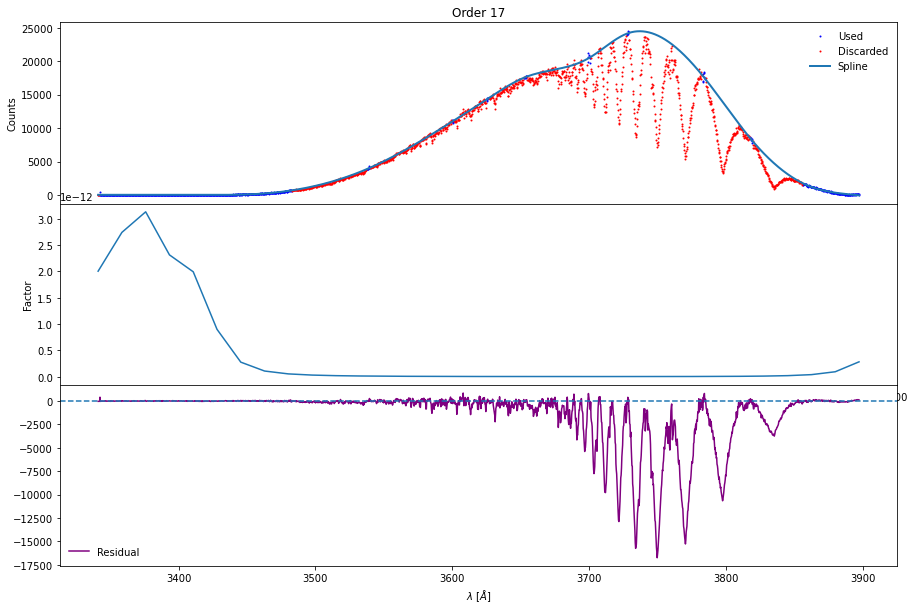

In [55]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr17[mask17_hr], yhr17[mask17_hr], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xhr17[np.logical_not(mask17_hr)], yhr17[np.logical_not(mask17_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(17), y_est_custom17_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 17')

axs[1].plot(simple_hr4963.lda, factor17_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(17), hr4963.flux(17) - y_est_custom17_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 18

In [56]:
xhr18 = hr4963.wavelength(18)
yhr18 = hr4963.flux(18)

mask18_hr = (xhr18 > 3207) * (xhr18 < 3355) \
          + (xhr18 > 3396) * (xhr18 < 3398) \
          + (xhr18 > 3419) * (xhr18 < 3421) \
          + (xhr18 > 3434) * (xhr18 < 3436) \
          + (xhr18 > 3469.8) * (xhr18 < 3470.9) \
          + (xhr18 > 3502.9) * (xhr18 < 3503.9) \
          + (xhr18 > 3561.9) * (xhr18 < 3563.7) \
          + (xhr18 > 3590)

knots18_hr = np.array([3230, 3290, 3306, 3325, 3350, 3397, 3420, 3435,
                       3470, 3503, 3563, 3616, 3651, 3675])

In [57]:
model_custom18_hr = get_natural_cubic_spline_model(x=xhr18[mask18_hr],
                                                   y=yhr18[mask18_hr],
                                                   minval=np.min(xhr18),
                                                   maxval=np.max(xhr18),
                                                   knots=knots18_hr)
y_est_custom18_hr = model_custom18_hr.predict(hr4963.wavelength(18))

In [58]:
obs_flux18_hr = spectres(simple_hr4963.lda, hr4963.wavelength(18),
                         y_est_custom18_hr, verbose=False)
factor18_hr = reference_hrflux(simple_hr4963.lda)/obs_flux18_hr

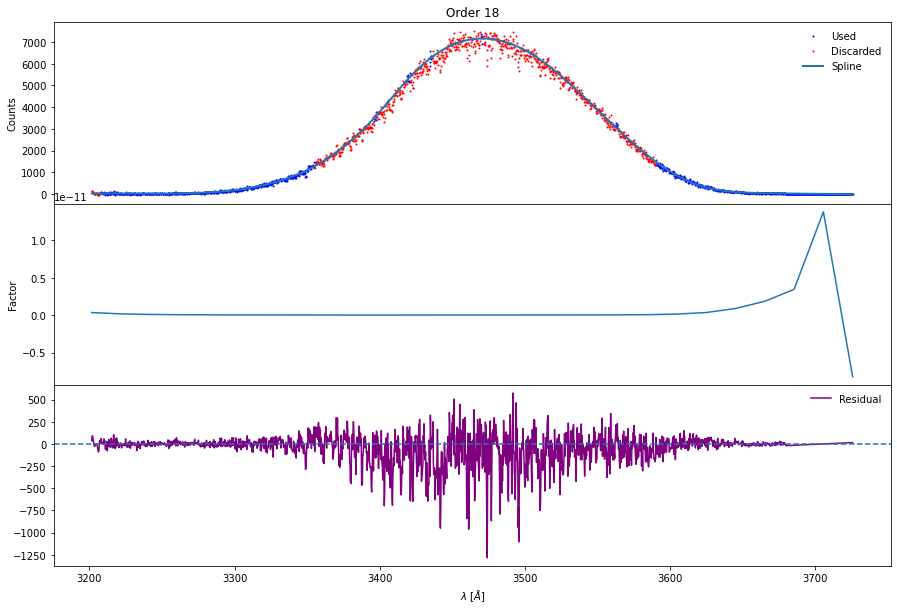

In [59]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr18[mask18_hr], yhr18[mask18_hr], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xhr18[np.logical_not(mask18_hr)], yhr18[np.logical_not(mask18_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(18), y_est_custom18_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 18')

axs[1].plot(simple_hr4963.lda, factor18_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(18), hr4963.flux(18) - y_est_custom18_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 19

In [60]:
c19hr = np.logical_and(hr4963.wavelength(19) > 3132,
                       hr4963.wavelength(19) < 3475) 
yhr19 = hr4963.flux(19)[c19hr]
xhr19 = hr4963.wavelength(19)[c19hr]

mask19_hr = (xhr19 > 3133) * (xhr19 < 3193) \
          + (xhr19 > 3208) * (xhr19 < 3212) \
          + (xhr19 > 3236) * (xhr19 < 3239) \
          + (xhr19 > 3268) * (xhr19 < 3270) \
          + (xhr19 > 3293.3) * (xhr19 < 3295) \
          + (xhr19 > 3324.6) * (xhr19 < 3325.8) \
          + (xhr19 > 3351) * (xhr19 < 3355) \
          + (xhr19 > 3378) * (xhr19 < 3476)

knots19_hr = np.array([3150, 3189, 3210, 3237.5, 3269, 3294, 3325, 3353,
                       3380, 3418, 3446, 3468])

In [61]:
model_custom19_hr = get_natural_cubic_spline_model(x=xhr19[mask19_hr],
                                                y=yhr19[mask19_hr],
                                                minval=np.min(xhr19),
                                                maxval=np.max(xhr19),
                                                knots=knots19_hr)
y_est_custom19_hr = model_custom19_hr.predict(hr4963.wavelength(19))

In [62]:
obs_flux19_hr = spectres(simple_hr4963.lda, hr4963.wavelength(19),
                         y_est_custom19_hr, verbose=False)
factor19_hr = reference_hrflux(simple_hr4963.lda)/obs_flux19_hr

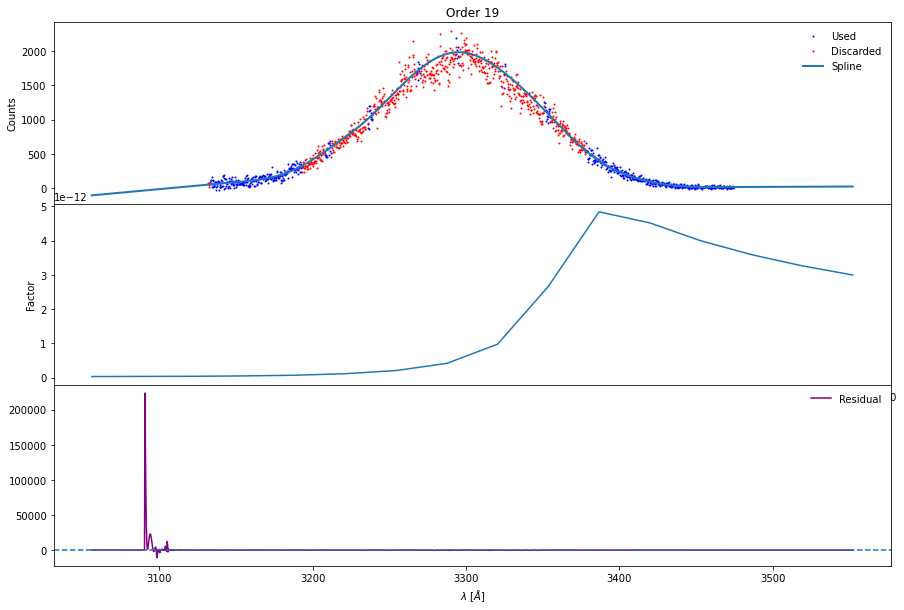

In [63]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr19[mask19_hr], yhr19[mask19_hr],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xhr19[np.logical_not(mask19_hr)],
            yhr19[np.logical_not(mask19_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(19), y_est_custom19_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 19')

axs[1].plot(simple_hr4963.lda, factor19_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(19), hr4963.flux(19) - y_est_custom19_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 20

In [64]:
yhr20 = hr4963.flux(20)#[ltt7379.wavelength(20) < 3300]
xhr20 = hr4963.wavelength(20)#[ltt7379.wavelength(20) < 3300]

mask20_ltt = (xltt20 > 3060) * (xltt20 < 3260)

knots20_ltt = np.array([3062, 3093, 3100, 3150, 3187, 3220, 3249])

NameError: name 'xltt20' is not defined

In [65]:
simple_hr4963.flux[:] = y_est_custom_model_hr

In [66]:
spline_flux_hr = [
    y_est_custom6_hr,
    y_est_custom7_hr,
    y_est_custom8_hr,
    y_est_custom9_hr,
    y_est_custom10_hr,
    y_est_custom11_hr,
    y_est_custom12_hr,
    y_est_custom13_hr,
    y_est_custom14_hr,
    y_est_custom15_hr,
    y_est_custom16_hr,
    y_est_custom17_hr,
    y_est_custom18_hr,
    y_est_custom19_hr,
]

In [67]:
for i in range(6, 20):
    hr4963.flux(i)[:] =  spline_flux_hr[i - 6]
    print('Order {:} succesful for HR'.format(i))

Order 6 succesful for HR
Order 7 succesful for HR
Order 8 succesful for HR
Order 9 succesful for HR
Order 10 succesful for HR
Order 11 succesful for HR
Order 12 succesful for HR
Order 13 succesful for HR
Order 14 succesful for HR
Order 15 succesful for HR
Order 16 succesful for HR
Order 17 succesful for HR
Order 18 succesful for HR
Order 19 succesful for HR


In [68]:
flux_calibrate_multispec(J1226, hr4963, simple_hr4963)
flux_calibrate_multispec(J2119, hr4963, simple_hr4963)

Flux calibrating order : 6

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 7

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 8

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 9

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 10

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 11

Spectres: new_wavs contains values 

/home/benjamin/Documents/analogs/magE/spec/spec_classes.py:182: RuntimeWarning: divide by zero encountered in true_divide
  calibration_factor = reference_flux(ref_lda) / obs_flux
/home/benjamin/Documents/analogs/magE/spec/spec_classes.py:184: RuntimeWarning: invalid value encountered in multiply
  calibrated_flux = multispec_target.flux(order) * calibration_factor


Flux calibrating order : 6

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 7

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 8

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 9

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 10

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 11

Spectres: new_wavs contains values 

In [ ]:
#J1226.to_fits("/home/benjamin/Documents/analogs/specs/fits/j1226+0415.fits")
#J2119.to_fits("/home/benjamin/Documents/analogs/specs/fits/j2119+0052.fits")

In [143]:
dict_orders = {6:[9500,10050],
               7:[8150,9470],
               8:[7130,8270],
               9:[6430,7340],
               10:[5835,6590],
               11:[5400,5950],
               12:[4850,5525],
               13:[4475,5080],
               14:[4220,4685],
               15:[3940,4300],
               16:[3740,4055]}

<ErrorbarContainer object of 3 artists>

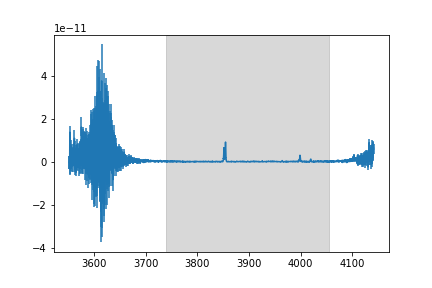

In [144]:
%matplotlib widget
i=16
plt.axvspan(dict_orders[i][0], dict_orders[i][1], color='gray', alpha=0.3)
plt.errorbar(J2119.wavelength(i), J2119.flux(i), J2119.noise(i))